In [1]:
### quick example on the binaryMNIST data
import os, sys
from pathlib import Path
from torch.utils.data import DataLoader

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / 'data').is_dir() and (current / 'data_setup').is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError('Could not locate necst-torch root directory')

REPO_ROOT = find_repo_root()
sys.path.append(str(REPO_ROOT))

from data_setup.dataloader import BinaryMNISTDataset, RandomBitsDataset  

DATA_ROOT = REPO_ROOT / 'data'

binmnist_root = DATA_ROOT / 'BinaryMNIST'
binmnist_train = BinaryMNISTDataset(str(binmnist_root / 'binarized_mnist_train.amat'))
binmnist_valid = BinaryMNISTDataset(str(binmnist_root / 'binarized_mnist_valid.amat'))
binmnist_test  = BinaryMNISTDataset(str(binmnist_root / 'binarized_mnist_test.amat'))

binary_train_loader = DataLoader(binmnist_train, batch_size=100, shuffle=True)
binary_valid_loader = DataLoader(binmnist_valid, batch_size=100, shuffle=False)
binary_test_loader  = DataLoader(binmnist_test,  batch_size=100, shuffle=False)

# quick sanity check
bin_batch = next(iter(binary_train_loader))
print("BinaryMNIST batch shape:", bin_batch.shape)

BinaryMNIST batch shape: torch.Size([100, 784])


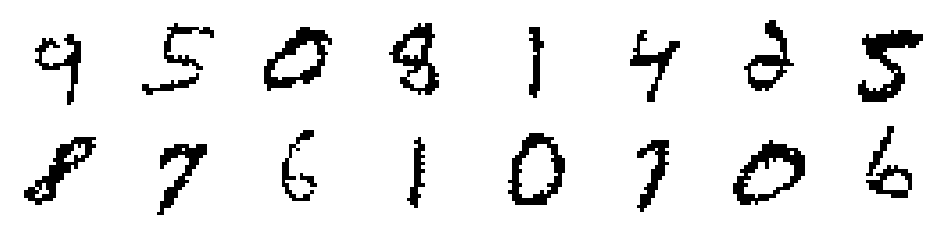

In [2]:
import matplotlib.pyplot as plt

def plot_binary_rows(data_loader, n_rows=2, n_cols=8, px=28):
    batch = next(iter(data_loader))
    images = batch[0] if isinstance(batch, (list, tuple)) else batch
    images = images[: n_rows * n_cols].detach().cpu()
    images = images.view(-1, px, px)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2))
    for idx, img in enumerate(images):
        row, col = divmod(idx, n_cols)
        axes[row, col].imshow(img, cmap="gray_r")
        axes[row, col].axis("off")
    plt.tight_layout()
    plt.show()

plot_binary_rows(binary_train_loader)

In [4]:
from src.necst import NecstTorch
from src.loss import Loss
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NecstTorch().to(device)
loss_fn = Loss(reg_param=model.reg_param, use_relaxation=True, temperature=0.67, hard=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(loader):
    model.train()
    running_loss = 0.0
    for batch in loader:
        batch = batch.to(device)

        logits = model.encoder(batch)
        z = loss_fn.gumbel_softmax(logits, hard=False)
        recon_logits = model.decoder(z)
        recon_probs = torch.sigmoid(recon_logits)
        qy = torch.softmax(logits / loss_fn.temperature, dim=-1)

        loss_value = loss_fn(model, recon_probs, batch, qy)

        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()

        running_loss += loss_value.item()
    return running_loss / len(loader)

for epoch in range(1, 5):
    avg_loss = train_epoch(binary_train_loader)
    print(f"[Gumbel] Epoch {epoch}: loss {avg_loss:.4f}")


[Gumbel] Epoch 1: loss 197.6647
[Gumbel] Epoch 2: loss 154.6080
[Gumbel] Epoch 3: loss 146.2023
[Gumbel] Epoch 4: loss 143.2737


In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F


def evaluate_model(loader, name):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, _, _, _, recon_logits = model.get_collapsed_stochastic_test_sample(batch)
            loss = F.binary_cross_entropy_with_logits(recon_logits, batch, reduction="sum")
            total_loss += loss.item()
    avg_loss = total_loss / len(loader.dataset)
    print(f"{name} avg BCE per sample: {avg_loss:.6f}")
    return avg_loss


def plot_reconstruction_pairs(original, reconstructed, n_pairs=8, shape=(28, 28), title=None):
    n_pairs = min(n_pairs, original.shape[0], reconstructed.shape[0])
    orig = original[:n_pairs].reshape(n_pairs, *shape)
    recon = reconstructed[:n_pairs].reshape(n_pairs, *shape)
    fig, axes = plt.subplots(2, n_pairs, figsize=(n_pairs * 1.4, 3), squeeze=False)
    for i in range(n_pairs):
        axes[0, i].imshow(orig[i], cmap="gray_r")
        axes[0, i].set_title("input")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i], cmap="gray_r")
        axes[1, i].set_title("recon")
        axes[1, i].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def display_reconstructions(loader, n_samples=8, shape=(28, 28), title=None):
    model.eval()
    dataset = loader.dataset
    indices = torch.randperm(len(dataset))[:n_samples]
    batch = torch.stack([dataset[i] for i in indices]).to(device)
    with torch.no_grad():
        _, _, _, _, recon_logits = model.get_collapsed_stochastic_test_sample(batch)
        recon_probs = torch.sigmoid(recon_logits)
    originals = batch.cpu().numpy()
    reconstructions = recon_probs.cpu().numpy()
    plot_reconstruction_pairs(
        originals, reconstructions, n_pairs=n_samples, shape=shape, title=title
    )

evaluate_model(binary_test_loader, "BinaryMNIST test")
evaluate_model(rand_test_loader, "Random bits test")

display_reconstructions(binary_test_loader, n_samples=8, shape=(28, 28), title="BinaryMNIST test reconstructions")
# display_reconstructions(rand_test_loader, n_samples=8, shape=(10, 10), title="Random bits test reconstructions")


In [ ]:
import torch
import matplotlib.pyplot as plt

def markov_chain_samples(model, start_samples=10, steps=3000, interval=500):
    model.eval()
    x_t = torch.bernoulli(torch.full((start_samples, 784), 0.5, device=device))
    snapshots = [x_t.cpu().numpy()]
    with torch.no_grad():
        for step in range(steps):
            _, _, _, _, recon_logits = model.get_collapsed_stochastic_test_sample(x_t)
            recon_probs = torch.sigmoid(recon_logits)
            x_t = torch.bernoulli(recon_probs.clamp(1e-6, 1 - 1e-6))
            if (step + 1) % interval == 0:
                snapshots.append(x_t.cpu().numpy())
    return snapshots

def plot_markov_chain(snapshots, interval=500, shape=(28, 28)):
    n_steps = len(snapshots)
    n_samples = snapshots[0].shape[0]
    fig, axes = plt.subplots(n_steps, n_samples, figsize=(n_samples * 1.2, n_steps * 1.2))
    for step_idx, snapshot in enumerate(snapshots):
        for sample_idx in range(n_samples):
            ax = axes[step_idx, sample_idx] if n_steps > 1 else axes[sample_idx]
            img = snapshot[sample_idx].reshape(shape)
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if sample_idx == 0:
                label_step = step_idx * interval if step_idx else 0
                ax.set_ylabel(f"Step {label_step}", rotation=0, labelpad=20, va="center")
    plt.tight_layout()
    plt.show()

snapshots = markov_chain_samples(model, start_samples=10, steps=2000, interval=500)
plot_markov_chain(snapshots, interval=1000)


In [ ]:
from src.necst import NecstTorch
from src.loss import Loss
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# using vimco loss
model = NecstTorch().to(device)

phi_opt = torch.optim.Adam(
    list(model.encoder_net.parameters()) + list(model.enc_out.parameters()), lr=1e-3,
)
theta_opt = torch.optim.Adam(
    list(model.decoder_net.parameters()) + list(model.dec_out.parameters()), lr=1e-3,
)

loss_fn = Loss(reg_param=model.reg_param, use_relaxation=False)

def train_epoch(loader):
    model.train()
    running_loss = 0.0
    for batch in loader:
        batch = batch.to(device)

        _, y, _, q, x_recon_logits = model.create_collapsed_computation_graph(batch)
        log_q_h = q.log_prob(y).sum(dim=-1)
        
        theta_loss, phi_loss, _ = loss_fn(model, batch, x_recon_logits, log_q_h)

        theta_opt.zero_grad()
        phi_opt.zero_grad()

        theta_loss.backward(retain_graph=True)
        phi_loss.backward()

        theta_opt.step()
        phi_opt.step()

        running_loss += theta_loss.item()
    return running_loss / len(loader)

for epoch in range(1, 100):
    avg_loss = train_epoch(binary_train_loader)
    print(f"Epoch {epoch}: θ-loss {avg_loss:.4f}")
